# Zone Entry Speed Analysis

Analyze player speed during zone entry plays to detect fatigue and stamina decline throughout the game.

*Note*: None of this made it into my final paper, but I found it interesting and wanted to presever it.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tracking = pd.read_parquet('../data/tracking.parquet')
events = pd.read_parquet('../data/events.parquet')
shifts = pd.read_parquet('../data/shifts.parquet')

print('Tracking shape:', tracking.shape)
print('Events shape:', events.shape)
print('Shifts shape:', shifts.shape)

Tracking shape: (8401602, 13)
Events shape: (19200, 21)
Shifts shape: (7861, 10)


In [24]:
# Extract zone entry events
zone_entries = events[events['Event'] == 'Zone Entry'].copy()
print(f'Total zone entries: {len(zone_entries)}')

# Create game identifier
zone_entries['Game'] = zone_entries['Date'] + ' ' + zone_entries['Home_Team'] + ' @ ' + zone_entries['Away_Team']
events['Game'] = events['Date'] + ' ' + events['Home_Team'] + ' @ ' + events['Away_Team']

# Tracking image names are formatted as: date away @ home; normalize to: date home @ away
tracking_game_raw = tracking['Image Id'].str.extract(r'(^\d{4}-\d{2}-\d{2}.*?)_')[0]
tracking_game_parts = tracking_game_raw.str.extract(r'^(\d{4}-\d{2}-\d{2})\s+(.*?)\s+@\s+(.*)$')
tracking['Game'] = (
    tracking_game_parts[0] + ' ' + tracking_game_parts[2] + ' @ ' + tracking_game_parts[1]
)

# Convert periods to numeric for sorting
zone_entries['Period_int'] = pd.to_numeric(zone_entries['Period'], errors='coerce')
events['Period_int'] = pd.to_numeric(events['Period'], errors='coerce')

# Create event sequence key for ordering within game/period
zone_entries['Event_Clock_Seconds'] = (
    zone_entries['Clock'].str.split(':').apply(
        lambda x: int(x[0]) * 60 + int(x[1])
    )
)
events['Event_Clock_Seconds'] = (
    events['Clock'].str.split(':').apply(
        lambda x: int(x[0]) * 60 + int(x[1])
    )
)

print('\nZone entry details:')
print(zone_entries[['Game', 'Period', 'Clock', 'Team', 'Player_Id', 'Event']].head(10))
print('\nTracking game key sample:')
print(tracking['Game'].dropna().head(5).tolist())

Total zone entries: 1507

Zone entry details:
                           Game  Period  Clock    Team Player_Id       Event
2    2025-10-11 Team D @ Team A       1  19:55  Team D        42  Zone Entry
14   2025-10-11 Team D @ Team A       1  19:30  Team A        29  Zone Entry
36   2025-10-11 Team D @ Team A       1  19:00  Team D        77  Zone Entry
40   2025-10-11 Team D @ Team A       1  18:48  Team A        20  Zone Entry
45   2025-10-11 Team D @ Team A       1  18:41  Team D        46  Zone Entry
59   2025-10-11 Team D @ Team A       1  18:14  Team D        46  Zone Entry
93   2025-10-11 Team D @ Team A       1  17:07  Team D        50  Zone Entry
121  2025-10-11 Team D @ Team A       1  16:19  Team A        92  Zone Entry
135  2025-10-11 Team D @ Team A       1  15:56  Team D        46  Zone Entry
139  2025-10-11 Team D @ Team A       1  15:47  Team A        20  Zone Entry

Tracking game key sample:
['2025-10-11 Team D @ Team A', '2025-10-11 Team D @ Team A', '2025-10-11 Team D 

In [25]:
# For each zone entry, find the next event and extract interval
zone_entry_intervals = []

for idx, ze in zone_entries.iterrows():
    game = ze['Game']
    period = ze['Period_int']
    player_id = ze['Player_Id']
    team = ze['Team']
    clock_sec = ze['Event_Clock_Seconds']
    
    if pd.isna(player_id) or pd.isna(period):
        continue
    
    # Convert countdown clock to elapsed game time (seconds since start of game)
    ze_elapsed = (period - 1) * 1200 + (1200 - clock_sec)
    
    # Candidate events in same game/team that occur after this zone entry
    game_events = events[
        (events['Game'] == game) &
        (events['Team'] == team) &
        (events['Period_int'].notna())
    ].copy()
    
    game_events['Elapsed_Seconds'] = (
        (game_events['Period_int'] - 1) * 1200 + (1200 - game_events['Event_Clock_Seconds'])
    )
    
    next_events = game_events[game_events['Elapsed_Seconds'] > ze_elapsed].sort_values('Elapsed_Seconds')
    
    if len(next_events) == 0:
        continue
    
    next_event = next_events.iloc[0]
    
    zone_entry_intervals.append({
        'Game': game,
        'Player_Id': player_id,
        'Team': team,
        'Zone_Entry_Period': period,
        'Zone_Entry_Clock': ze['Clock'],
        'Zone_Entry_Clock_Seconds': clock_sec,
        'Next_Event': next_event['Event'],
        'Next_Event_Period': next_event['Period_int'],
        'Next_Event_Clock': next_event['Clock'],
        'Next_Event_Clock_Seconds': next_event['Event_Clock_Seconds'],
    })

ze_intervals = pd.DataFrame(zone_entry_intervals)
print(f'Zone entry intervals extracted: {len(ze_intervals)}')
print(ze_intervals.head(10))

Zone entry intervals extracted: 1490
                         Game Player_Id    Team  Zone_Entry_Period  \
0  2025-10-11 Team D @ Team A        42  Team D                  1   
1  2025-10-11 Team D @ Team A        29  Team A                  1   
2  2025-10-11 Team D @ Team A        77  Team D                  1   
3  2025-10-11 Team D @ Team A        20  Team A                  1   
4  2025-10-11 Team D @ Team A        46  Team D                  1   
5  2025-10-11 Team D @ Team A        46  Team D                  1   
6  2025-10-11 Team D @ Team A        50  Team D                  1   
7  2025-10-11 Team D @ Team A        92  Team A                  1   
8  2025-10-11 Team D @ Team A        46  Team D                  1   
9  2025-10-11 Team D @ Team A        20  Team A                  1   

  Zone_Entry_Clock  Zone_Entry_Clock_Seconds       Next_Event  \
0            19:55                      1195             Shot   
1            19:30                      1170    Puck Recovery 

In [26]:
# Extract speed data for each interval
skaters = tracking[tracking['Player or Puck'] == 'Player'].copy()
skaters['Period_int'] = pd.to_numeric(skaters['Period'], errors='coerce')
skaters['image_num'] = skaters['Image Id'].str.extract(r'_(\d+)$')[0].astype(float)
skaters['game_seconds'] = (
    skaters['Game Clock'].str.split(':').apply(
        lambda x: int(x[0]) * 60 + int(x[1]) if isinstance(x, list) and len(x) == 2 else np.nan
    )
)

# Check for speed columns
speed_cols = [c for c in skaters.columns if 'speed' in c.lower()]
print('Available speed columns:', speed_cols)
if 'speed_mph_savgol' in speed_cols:
    print('Using speed_mph_savgol')
    skaters['speed'] = skaters['speed_mph_savgol']
elif 'speed_mph_raw' in speed_cols:
    print('Using speed_mph_raw')
    skaters['speed'] = skaters['speed_mph_raw']
else:
    print('No speed columns found - will compute from tracking')

Available speed columns: ['speed_mph_raw', 'speed_mph_savgol']
Using speed_mph_savgol


In [27]:
# Match tracking data to zone entry intervals
interval_speeds = []

for idx, interval in ze_intervals.iterrows():
    if idx % 200 == 0:
        print(f'Processing interval {idx}/{len(ze_intervals)}')
    
    game = interval['Game']
    player_id = interval['Player_Id']
    ze_period = int(interval['Zone_Entry_Period'])
    next_period = int(interval['Next_Event_Period'])
    ze_clock_sec = interval['Zone_Entry_Clock_Seconds']
    next_clock_sec = interval['Next_Event_Clock_Seconds']
    
    # Filter tracking data for this player during this game
    # Note: shifts.Player_Id corresponds to tracking.Player Jersey Number, not Player Id
    player_tracking = skaters[
        (skaters['Game'] == game) & 
        (skaters['Player Jersey Number'] == str(player_id))
    ].copy()
    
    if len(player_tracking) == 0:
        continue
    
    # Game clock counts down, so interval bounds are reversed within a period
    if ze_period == next_period:
        interval_data = player_tracking[
            (player_tracking['Period_int'] == ze_period) &
            (player_tracking['game_seconds'] <= ze_clock_sec) &
            (player_tracking['game_seconds'] >= next_clock_sec)
        ]
    else:
        interval_data = player_tracking[
            ((player_tracking['Period_int'] == ze_period) & (player_tracking['game_seconds'] <= ze_clock_sec)) |
            ((player_tracking['Period_int'] > ze_period) & (player_tracking['Period_int'] < next_period)) |
            ((player_tracking['Period_int'] == next_period) & (player_tracking['game_seconds'] >= next_clock_sec))
        ]
    
    if 'speed_mph_savgol' not in interval_data.columns or len(interval_data) == 0:
        continue
    
    valid_speeds = interval_data['speed_mph_savgol'].dropna()
    if len(valid_speeds) == 0:
        continue
    
    interval_speeds.append({
        'Game': game,
        'Player_Id': player_id,
        'Team': interval['Team'],
        'Zone_Entry_Period': ze_period,
        'Zone_Entry_Clock': interval['Zone_Entry_Clock'],
        'Next_Event': interval['Next_Event'],
        'Max_Speed': valid_speeds.max(),
        'Mean_Speed': valid_speeds.mean(),
        'Median_Speed': valid_speeds.median(),
        'Speed_Count': len(valid_speeds),
    })

ze_speeds = pd.DataFrame(interval_speeds)
print(f'\nZone entry intervals with speed data: {len(ze_speeds)}')
print(ze_speeds.head(15))

Processing interval 0/1490
Processing interval 200/1490
Processing interval 400/1490
Processing interval 600/1490
Processing interval 800/1490
Processing interval 1000/1490
Processing interval 1200/1490
Processing interval 1400/1490

Zone entry intervals with speed data: 1232
                          Game Player_Id    Team  Zone_Entry_Period  \
0   2025-10-11 Team D @ Team A        42  Team D                  1   
1   2025-10-11 Team D @ Team A        29  Team A                  1   
2   2025-10-11 Team D @ Team A        77  Team D                  1   
3   2025-10-11 Team D @ Team A        20  Team A                  1   
4   2025-10-11 Team D @ Team A        46  Team D                  1   
5   2025-10-11 Team D @ Team A        46  Team D                  1   
6   2025-10-11 Team D @ Team A        50  Team D                  1   
7   2025-10-11 Team D @ Team A        92  Team A                  1   
8   2025-10-11 Team D @ Team A        46  Team D                  1   
9   2025-10-1

Speed metrics by Period during Zone Entries:
                  Max_Speed                     Mean_Speed
                      count   mean median   std       mean
Zone_Entry_Period                                         
1                       469  18.71  19.16  3.51      12.92
2                       453  18.24  18.70  3.77      12.54
3                       310  18.16  18.89  3.65      12.70


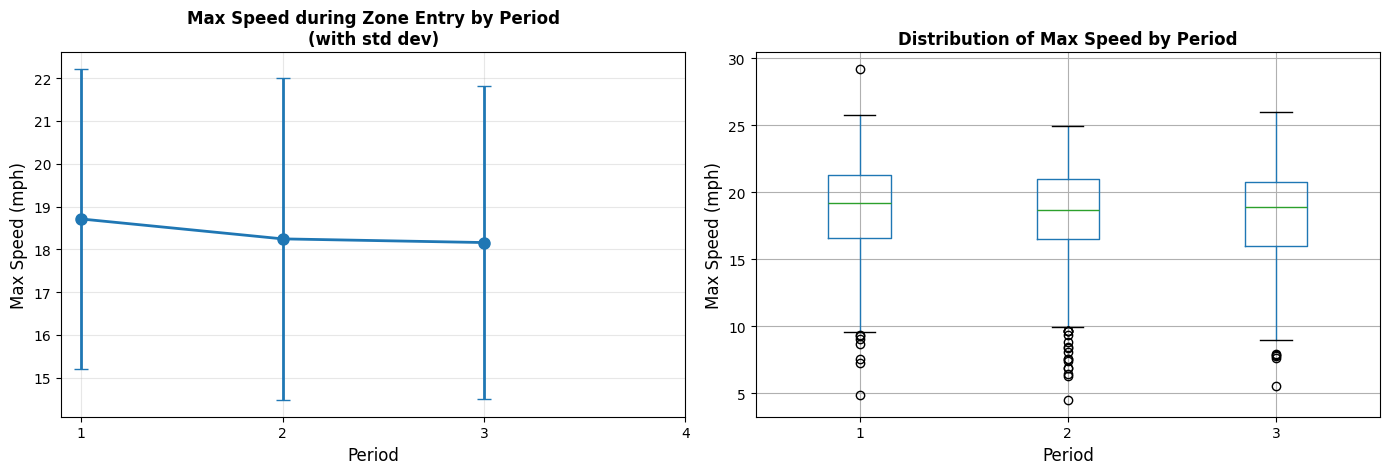


Observation: Does max speed decline as the period progresses?


In [28]:
# Analyze speed decline by period
period_analysis = ze_speeds.groupby('Zone_Entry_Period').agg({
    'Max_Speed': ['count', 'mean', 'median', 'std'],
    'Mean_Speed': 'mean',
}).round(2)

print('Speed metrics by Period during Zone Entries:')
print(period_analysis)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Max speed by period
period_max = ze_speeds.groupby('Zone_Entry_Period')['Max_Speed'].agg(['mean', 'std'])
axes[0].errorbar(period_max.index, period_max['mean'], yerr=period_max['std'], 
                  fmt='o-', capsize=5, linewidth=2, markersize=8)
axes[0].set_xlabel('Period', fontsize=12)
axes[0].set_ylabel('Max Speed (mph)', fontsize=12)
axes[0].set_title('Max Speed during Zone Entry by Period\n(with std dev)', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].set_xticks([1, 2, 3, 4])

# Distribution by period (boxplot)
ze_speeds.boxplot(column='Max_Speed', by='Zone_Entry_Period', ax=axes[1])
axes[1].set_xlabel('Period', fontsize=12)
axes[1].set_ylabel('Max Speed (mph)', fontsize=12)
axes[1].set_title('Distribution of Max Speed by Period', fontsize=12, fontweight='bold')
plt.suptitle('')

plt.tight_layout()
plt.show()

print('\nObservation: Does max speed decline as the period progresses?')

In [29]:
# Analyze by game and player (stamina metric)
# For each player per game, track max speed in each period

player_game_period = ze_speeds.groupby(['Game', 'Player_Id', 'Zone_Entry_Period']).agg({
    'Max_Speed': ['mean', 'count'],
    'Mean_Speed': 'mean',
}).reset_index()

player_game_period.columns = ['Game', 'Player_Id', 'Period', 'Max_Speed', 'Play_Count', 'Mean_Speed']

# For each player-game, calculate speed decline from P1 to P3
player_game_decline = []

for (game, player), group in player_game_period.groupby(['Game', 'Player_Id']):
    periods_in_game = sorted(group['Period'].unique())
    
    if 1.0 in periods_in_game and len(periods_in_game) >= 2:
        p1_max = group[group['Period'] == 1.0]['Max_Speed'].values
        
        for period in periods_in_game[1:]:
            p_max = group[group['Period'] == period]['Max_Speed'].values
            
            if len(p1_max) > 0 and len(p_max) > 0:
                speed_decline = p1_max[0] - p_max[0]
                pct_decline = (speed_decline / p1_max[0]) * 100 if p1_max[0] > 0 else 0
                
                player_game_decline.append({
                    'Game': game,
                    'Player_Id': player,
                    'P1_Max_Speed': p1_max[0],
                    'Current_Period': period,
                    'Current_Max_Speed': p_max[0],
                    'Speed_Decline_mph': speed_decline,
                    'Speed_Decline_pct': pct_decline,
                })

decline_df = pd.DataFrame(player_game_decline)
print(f'Players with speed decline tracked: {len(decline_df)}')
print('\nDecline statistics:')
print(decline_df[['Speed_Decline_mph', 'Speed_Decline_pct']].describe())

print('\nSample declines:')
print(decline_df.nlargest(10, 'Speed_Decline_pct')[['Game', 'Player_Id', 'Current_Period', 'P1_Max_Speed', 'Current_Max_Speed', 'Speed_Decline_pct']])

Players with speed decline tracked: 310

Decline statistics:
       Speed_Decline_mph  Speed_Decline_pct
count         310.000000         310.000000
mean            0.585180           0.996497
std             3.962799          23.683715
min           -13.561486        -144.978486
25%            -2.008716         -10.843508
50%             0.457924           2.443512
75%             2.865638          13.980878
max            13.746710          73.079681

Sample declines:
                           Game Player_Id  Current_Period  P1_Max_Speed  \
95   2025-10-24 Team A @ Team B        48               2     16.718576   
59   2025-10-17 Team L @ Team F        28               3     18.549157   
240  2025-11-16 Team K @ Team H        49               2     21.183739   
58   2025-10-17 Team L @ Team F        28               2     18.549157   
137  2025-10-28 Team A @ Team C         2               3     21.537496   
67   2025-10-17 Team L @ Team F        42               3     21.328877   


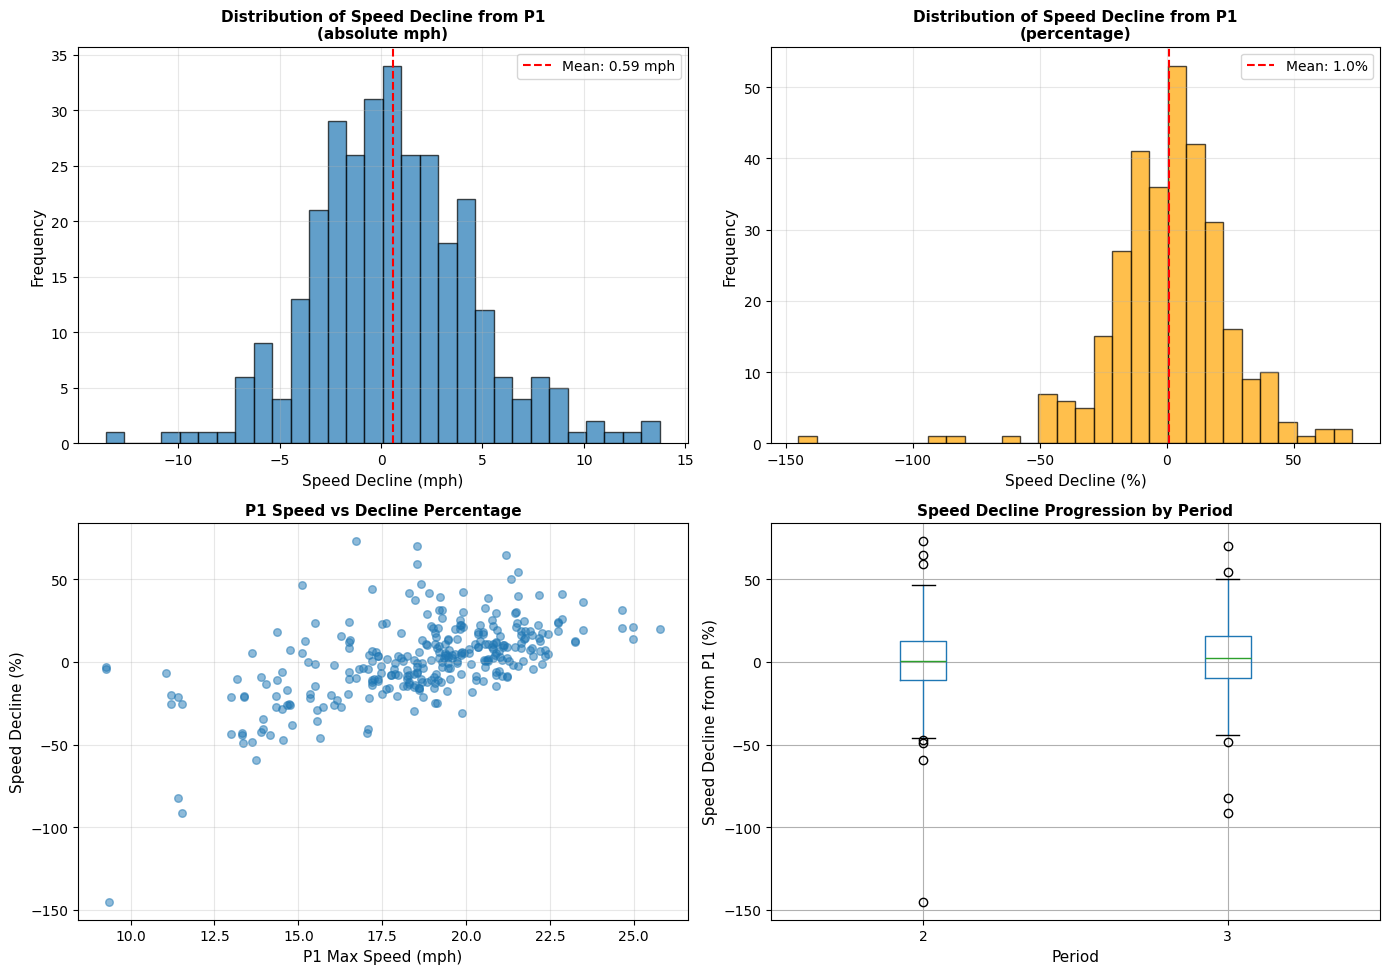

In [30]:
# Visualize decline patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram of speed decline (mph)
axes[0, 0].hist(decline_df['Speed_Decline_mph'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Speed Decline (mph)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Distribution of Speed Decline from P1\n(absolute mph)', fontsize=11, fontweight='bold')
axes[0, 0].axvline(decline_df['Speed_Decline_mph'].mean(), color='red', linestyle='--', label=f'Mean: {decline_df["Speed_Decline_mph"].mean():.2f} mph')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Histogram of speed decline (percent)
axes[0, 1].hist(decline_df['Speed_Decline_pct'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Speed Decline (%)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Distribution of Speed Decline from P1\n(percentage)', fontsize=11, fontweight='bold')
axes[0, 1].axvline(decline_df['Speed_Decline_pct'].mean(), color='red', linestyle='--', label=f'Mean: {decline_df["Speed_Decline_pct"].mean():.1f}%')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Scatter: P1 speed vs decline
axes[1, 0].scatter(decline_df['P1_Max_Speed'], decline_df['Speed_Decline_pct'], alpha=0.5, s=30)
axes[1, 0].set_xlabel('P1 Max Speed (mph)', fontsize=11)
axes[1, 0].set_ylabel('Speed Decline (%)', fontsize=11)
axes[1, 0].set_title('P1 Speed vs Decline Percentage', fontsize=11, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Box plot by period
decline_df.boxplot(column='Speed_Decline_pct', by='Current_Period', ax=axes[1, 1])
axes[1, 1].set_xlabel('Period', fontsize=11)
axes[1, 1].set_ylabel('Speed Decline from P1 (%)', fontsize=11)
axes[1, 1].set_title('Speed Decline Progression by Period', fontsize=11, fontweight='bold')
plt.suptitle('')

plt.tight_layout()
plt.show()

In [31]:
# Calculate stamina score: average decline rate per period
stamina_scores = []

for (game, player), group in decline_df.groupby(['Game', 'Player_Id']):
    group = group.sort_values('Current_Period')
    
    # Average percent decline per period
    avg_decline_per_period = group['Speed_Decline_pct'].mean()
    
    # Slope of decline (if multiple periods)
    if len(group) > 1:
        slope = (group['Speed_Decline_pct'].iloc[-1] - group['Speed_Decline_pct'].iloc[0]) / (len(group) - 1)
    else:
        slope = 0
    
    # Max decline observed
    max_decline = group['Speed_Decline_pct'].max()
    p1_speed = group['P1_Max_Speed'].iloc[0] if len(group) > 0 else 0
    
    stamina_scores.append({
        'Game': game,
        'Player_Id': player,
        'P1_Max_Speed': p1_speed,
        'Avg_Decline_pct': avg_decline_per_period,
        'Decline_Slope': slope,
        'Max_Decline_pct': max_decline,
        'Periods_Observed': len(group),
    })

stamina_df = pd.DataFrame(stamina_scores)
print('Stamina Score Summary (lower decline = better stamina):')
print(stamina_df[['Avg_Decline_pct', 'Max_Decline_pct', 'Decline_Slope']].describe())

print('\nBest stamina (lowest decline):') 
print(stamina_df.nsmallest(10, 'Avg_Decline_pct')[['Game', 'Player_Id', 'P1_Max_Speed', 'Avg_Decline_pct', 'Decline_Slope']])

print('\nWorst stamina (highest decline):')
print(stamina_df.nlargest(10, 'Avg_Decline_pct')[['Game', 'Player_Id', 'P1_Max_Speed', 'Avg_Decline_pct', 'Decline_Slope']])

Stamina Score Summary (lower decline = better stamina):
       Avg_Decline_pct  Max_Decline_pct  Decline_Slope
count       202.000000       202.000000     202.000000
mean          0.874499         5.605226      -0.330287
std          22.984337        24.029105      17.670622
min        -144.978486      -144.978486     -82.655665
25%          -8.400624        -5.510461      -1.323790
50%           1.844103         5.770969       0.000000
75%          13.093879        18.985982       0.237193
max          64.892749        73.079681      57.473591

Best stamina (lowest decline):
                           Game Player_Id  P1_Max_Speed  Avg_Decline_pct  \
82   2025-10-24 Team D @ Team E        78      9.354137      -144.978486   
81   2025-10-24 Team D @ Team E        51     13.736228       -59.581211   
7    2025-10-11 Team D @ Team A        37     11.529776       -58.634875   
55   2025-10-24 Team A @ Team B        37     11.405658       -51.737258   
78   2025-10-24 Team D @ Team E      

In [32]:
# Final assessment: is this a good stamina metric?
print('=== ZONE ENTRY SPEED DECLINE AS STAMINA METRIC ===')
print()
print('STRENGTHS:')
print('1. Captures intensity of play during offensive transition')
print('2. Directly observable decline from early to late game')
print('3. Per-player and per-game quantifiable')
print()
print('OBSERVATIONS:')
print(f'  - Mean decline from P1: {stamina_df["Avg_Decline_pct"].mean():.1f}%')
print(f'  - Std deviation: {stamina_df["Avg_Decline_pct"].std():.1f}%')
print(f'  - Range: {stamina_df["Avg_Decline_pct"].min():.1f}% to {stamina_df["Avg_Decline_pct"].max():.1f}%')
print()
print('POTENTIAL ISSUES:')
print('1. Depends on quality of zone entry tracking (Detail_1 might matter)')
print('2. May confound fatigue with strategy changes')
print('3. Requires sufficient zone entries per player-game')
print()
print('RECOMMENDATION:')
print('Use as SECONDARY stamina metric alongside:')
print('  - Shift-by-shift speed analysis')
print('  - Distance traveled per shift')
print('  - Average speed decline across all plays (not just zone entries)')

=== ZONE ENTRY SPEED DECLINE AS STAMINA METRIC ===

STRENGTHS:
1. Captures intensity of play during offensive transition
2. Directly observable decline from early to late game
3. Per-player and per-game quantifiable

OBSERVATIONS:
  - Mean decline from P1: 0.9%
  - Std deviation: 23.0%
  - Range: -145.0% to 64.9%

POTENTIAL ISSUES:
1. Depends on quality of zone entry tracking (Detail_1 might matter)
2. May confound fatigue with strategy changes
3. Requires sufficient zone entries per player-game

RECOMMENDATION:
Use as SECONDARY stamina metric alongside:
  - Shift-by-shift speed analysis
  - Distance traveled per shift
  - Average speed decline across all plays (not just zone entries)


## Shift Time vs Speed Decline Analysis
Analyze how total shift time correlates with speed decline, using slope-based metrics within periods and games.

In [34]:
# Prepare shifts data with game identifier matching events/tracking format
shifts['Game'] = shifts['Date'] + ' ' + shifts['Home_Team'] + ' @ ' + shifts['Away_Team']

# Parse shift_length from MM:SS to seconds
shifts['Duration_s'] = (
    shifts['shift_length'].str.split(':').apply(
        lambda x: int(x[0]) * 60 + int(x[1]) if isinstance(x, list) and len(x) == 2 else 0
    )
)

# Aggregate shift times per player per period per game
shift_by_period = shifts.groupby(['Game', 'Player_Id', 'period']).agg({
    'Duration_s': 'sum',
}).reset_index()
shift_by_period.columns = ['Game', 'Player_Id', 'Period', 'Total_Shift_Time_s']

# Aggregate shift times per player per game
shift_by_game = shifts.groupby(['Game', 'Player_Id']).agg({
    'Duration_s': 'sum',
}).reset_index()
shift_by_game.columns = ['Game', 'Player_Id', 'Total_Game_Shift_Time_s']

print('Shift aggregation:')
print(f'  - By period: {len(shift_by_period)} records')
print(f'  - By game: {len(shift_by_game)} records')
print('\nShift time by period sample:')
print(shift_by_period.head(10))

Shift aggregation:
  - By period: 1042 records
  - By game: 330 records

Shift time by period sample:
                         Game Player_Id  Period  Total_Shift_Time_s
0  2025-10-11 Team D @ Team A        12       1                 394
1  2025-10-11 Team D @ Team A        12       2                 327
2  2025-10-11 Team D @ Team A        12       3                 447
3  2025-10-11 Team D @ Team A        14       1                 248
4  2025-10-11 Team D @ Team A        14       2                 261
5  2025-10-11 Team D @ Team A        14       3                 314
6  2025-10-11 Team D @ Team A        17       1                 216
7  2025-10-11 Team D @ Team A        17       2                 258
8  2025-10-11 Team D @ Team A        17       3                 222
9  2025-10-11 Team D @ Team A        20       1                 372


In [35]:
# Calculate speed decline slopes WITHIN each period for each player-game
# For each player-game-period, compute linear slope of max speeds across zone entries

from scipy import stats

period_speed_slopes = []

for (game, player, period), group in ze_speeds.groupby(['Game', 'Player_Id', 'Zone_Entry_Period']):
    if len(group) >= 2:  # Need at least 2 points for slope
        # Use zone entry order within period as x-axis
        group_sorted = group.sort_values('Zone_Entry_Clock', ascending=False)  # Chronological (clock counts down)
        x = np.arange(len(group_sorted))
        y = group_sorted['Max_Speed'].values
        
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        
        period_speed_slopes.append({
            'Game': game,
            'Player_Id': player,
            'Period': period,
            'Speed_Slope_Within_Period': slope,  # mph per zone entry
            'R_squared': r_value**2,
            'Zone_Entries_Count': len(group),
            'First_Max_Speed': y[0],
            'Last_Max_Speed': y[-1],
        })

period_slopes_df = pd.DataFrame(period_speed_slopes)
print(f'Period-level speed slopes calculated: {len(period_slopes_df)}')
print('\nSample period slopes:')
print(period_slopes_df.head(10))
print('\nSlope statistics (within period):')
print(period_slopes_df['Speed_Slope_Within_Period'].describe())

Period-level speed slopes calculated: 332

Sample period slopes:
                         Game Player_Id  Period  Speed_Slope_Within_Period  \
0  2025-10-11 Team D @ Team A        12       2                   7.354986   
1  2025-10-11 Team D @ Team A        14       2                   7.782324   
2  2025-10-11 Team D @ Team A        20       1                   1.598687   
3  2025-10-11 Team D @ Team A        25       1                   1.600349   
4  2025-10-11 Team D @ Team A        28       2                   0.666337   
5  2025-10-11 Team D @ Team A        29       1                  -0.008597   
6  2025-10-11 Team D @ Team A        29       2                  -1.934661   
7  2025-10-11 Team D @ Team A        29       3                  -2.655426   
8  2025-10-11 Team D @ Team A        36       2                  -0.948581   
9  2025-10-11 Team D @ Team A        36       3                  -2.303697   

   R_squared  Zone_Entries_Count  First_Max_Speed  Last_Max_Speed  
0   1.00

In [36]:
# Calculate speed decline slopes ACROSS periods for each player-game
# For each player-game, compute slope of max speeds across all zone entries throughout the game

game_speed_slopes = []

for (game, player), group in ze_speeds.groupby(['Game', 'Player_Id']):
    if len(group) >= 3:  # Need multiple entries for meaningful slope
        # Sort chronologically across all periods
        group_sorted = group.sort_values(['Zone_Entry_Period', 'Zone_Entry_Clock'], ascending=[True, False])
        x = np.arange(len(group_sorted))
        y = group_sorted['Max_Speed'].values
        
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        
        # Also compute period-to-period decline
        periods = sorted(group['Zone_Entry_Period'].unique())
        period_avgs = [group[group['Zone_Entry_Period'] == p]['Max_Speed'].mean() for p in periods]
        
        if len(periods) >= 2:
            period_slope = (period_avgs[-1] - period_avgs[0]) / (len(periods) - 1)
        else:
            period_slope = 0
        
        game_speed_slopes.append({
            'Game': game,
            'Player_Id': player,
            'Speed_Slope_Within_Game': slope,  # mph per zone entry across game
            'R_squared': r_value**2,
            'Zone_Entries_Count': len(group),
            'Periods_Played': len(periods),
            'First_Max_Speed': y[0],
            'Last_Max_Speed': y[-1],
            'Period_Avg_Slope': period_slope,  # mph change per period
        })

game_slopes_df = pd.DataFrame(game_speed_slopes)
print(f'Game-level speed slopes calculated: {len(game_slopes_df)}')
print('\nSample game slopes:')
print(game_slopes_df.head(10))
print('\nSlope statistics (within game):')
print(game_slopes_df['Speed_Slope_Within_Game'].describe())

Game-level speed slopes calculated: 198

Sample game slopes:
                         Game Player_Id  Speed_Slope_Within_Game  R_squared  \
0  2025-10-11 Team D @ Team A        12                 2.068092   0.355726   
1  2025-10-11 Team D @ Team A        14                -2.270421   0.132717   
2  2025-10-11 Team D @ Team A        20                 1.890387   0.967767   
3  2025-10-11 Team D @ Team A        25                 0.998932   0.653022   
4  2025-10-11 Team D @ Team A        28                 0.762334   0.411090   
5  2025-10-11 Team D @ Team A        29                -0.530611   0.308029   
6  2025-10-11 Team D @ Team A        36                -0.458266   0.485852   
7  2025-10-11 Team D @ Team A        37                 2.281708   0.259835   
8  2025-10-11 Team D @ Team A        39                 0.459973   0.174666   
9  2025-10-11 Team D @ Team A        42                -0.782214   0.345347   

   Zone_Entries_Count  Periods_Played  First_Max_Speed  Last_Max_Spee

Period analysis records: 332

Correlation between shift time and speed decline within period:
                           Total_Shift_Time_s  Speed_Slope_Within_Period
Total_Shift_Time_s                    1.00000                   -0.05749
Speed_Slope_Within_Period            -0.05749                    1.00000


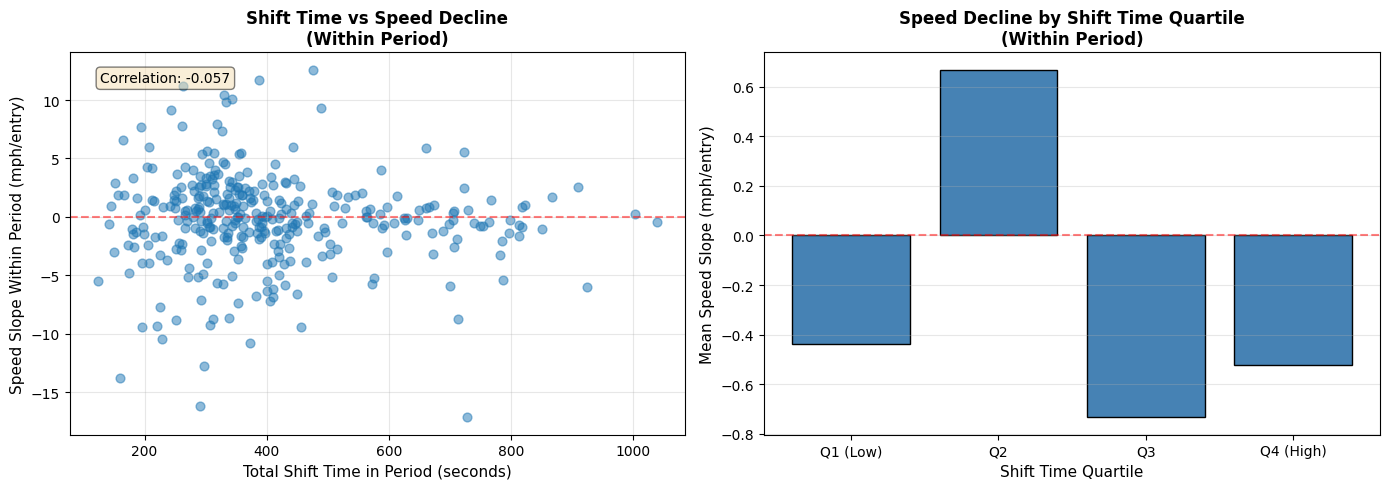

In [37]:
# Merge shift time with speed slopes for period-level analysis
period_analysis_df = period_slopes_df.merge(
    shift_by_period,
    on=['Game', 'Player_Id', 'Period'],
    how='inner'
)

print(f'Period analysis records: {len(period_analysis_df)}')
print('\nCorrelation between shift time and speed decline within period:')
correlation_period = period_analysis_df[['Total_Shift_Time_s', 'Speed_Slope_Within_Period']].corr()
print(correlation_period)

# Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(period_analysis_df['Total_Shift_Time_s'], 
                period_analysis_df['Speed_Slope_Within_Period'], 
                alpha=0.5, s=40)
axes[0].set_xlabel('Total Shift Time in Period (seconds)', fontsize=11)
axes[0].set_ylabel('Speed Slope Within Period (mph/entry)', fontsize=11)
axes[0].set_title('Shift Time vs Speed Decline\n(Within Period)', fontsize=12, fontweight='bold')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0].grid(alpha=0.3)

# Add correlation text
corr_val = period_analysis_df['Total_Shift_Time_s'].corr(period_analysis_df['Speed_Slope_Within_Period'])
axes[0].text(0.05, 0.95, f'Correlation: {corr_val:.3f}', 
             transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Bin by shift time quartiles
period_analysis_df['Shift_Time_Quartile'] = pd.qcut(period_analysis_df['Total_Shift_Time_s'], 
                                                      q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])
quartile_slopes = period_analysis_df.groupby('Shift_Time_Quartile')['Speed_Slope_Within_Period'].mean()

axes[1].bar(range(len(quartile_slopes)), quartile_slopes.values, color='steelblue', edgecolor='black')
axes[1].set_xticks(range(len(quartile_slopes)))
axes[1].set_xticklabels(quartile_slopes.index, fontsize=10)
axes[1].set_ylabel('Mean Speed Slope (mph/entry)', fontsize=11)
axes[1].set_xlabel('Shift Time Quartile', fontsize=11)
axes[1].set_title('Speed Decline by Shift Time Quartile\n(Within Period)', fontsize=12, fontweight='bold')
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Game analysis records: 198

Correlation between game shift time and speed decline:
  Speed_Slope_Within_Game (per entry):
    Correlation: -0.010
  Period_Avg_Slope (per period):
    Correlation: 0.007


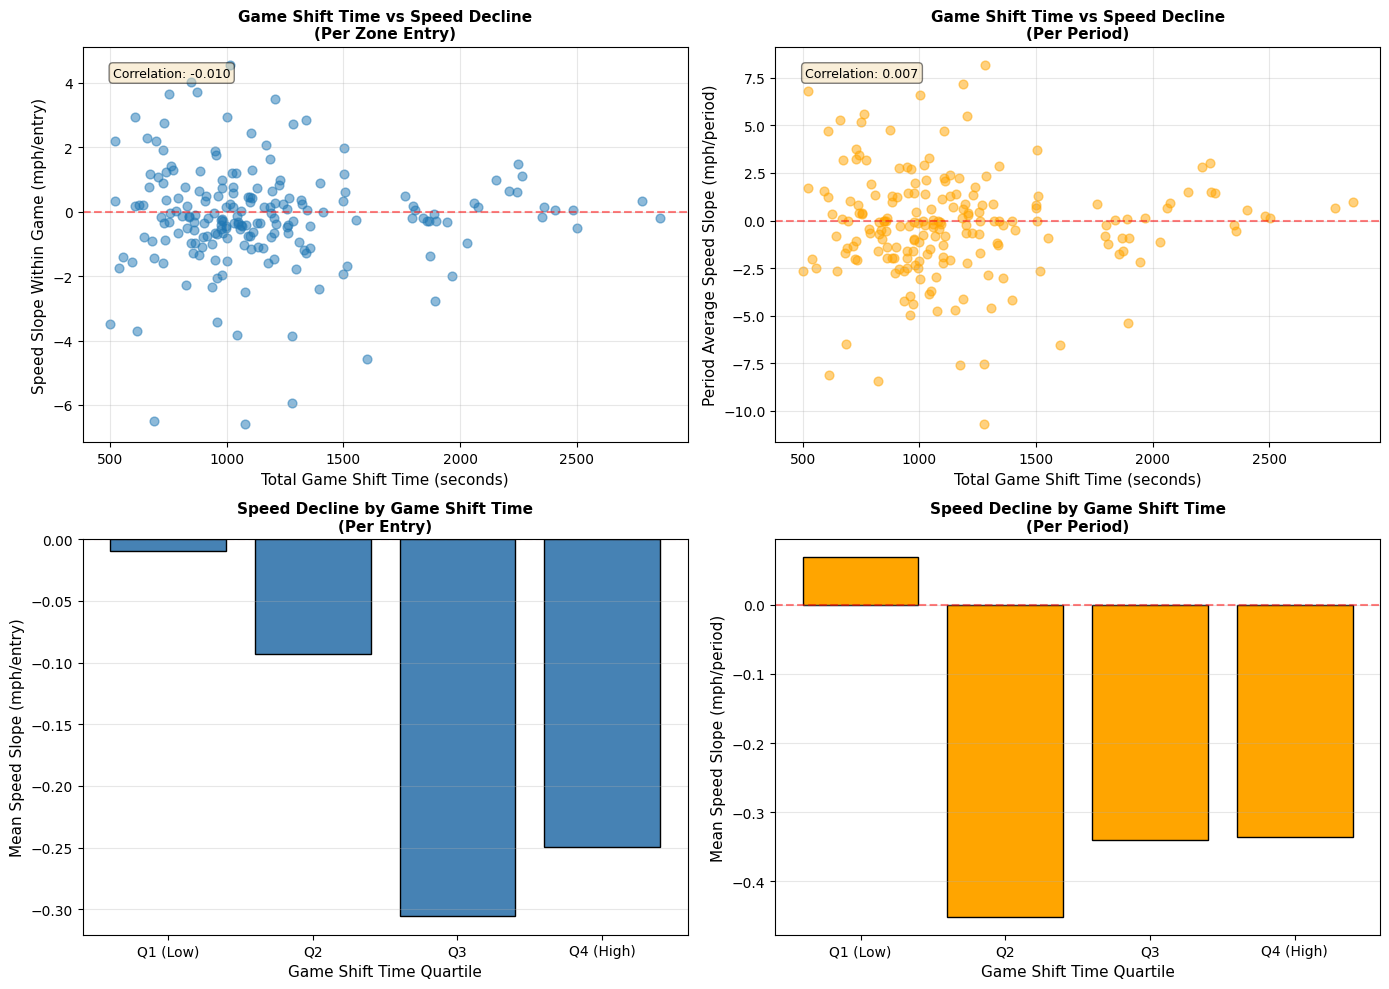

In [38]:
# Merge shift time with speed slopes for game-level analysis
game_analysis_df = game_slopes_df.merge(
    shift_by_game,
    on=['Game', 'Player_Id'],
    how='inner'
)

print(f'Game analysis records: {len(game_analysis_df)}')
print('\nCorrelation between game shift time and speed decline:')
print('  Speed_Slope_Within_Game (per entry):')
corr1 = game_analysis_df['Total_Game_Shift_Time_s'].corr(game_analysis_df['Speed_Slope_Within_Game'])
print(f'    Correlation: {corr1:.3f}')
print('  Period_Avg_Slope (per period):')
corr2 = game_analysis_df['Total_Game_Shift_Time_s'].corr(game_analysis_df['Period_Avg_Slope'])
print(f'    Correlation: {corr2:.3f}')

# Scatter plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top left: shift time vs speed slope (per entry)
axes[0, 0].scatter(game_analysis_df['Total_Game_Shift_Time_s'], 
                   game_analysis_df['Speed_Slope_Within_Game'], 
                   alpha=0.5, s=40)
axes[0, 0].set_xlabel('Total Game Shift Time (seconds)', fontsize=11)
axes[0, 0].set_ylabel('Speed Slope Within Game (mph/entry)', fontsize=11)
axes[0, 0].set_title('Game Shift Time vs Speed Decline\n(Per Zone Entry)', fontsize=11, fontweight='bold')
axes[0, 0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 0].grid(alpha=0.3)
axes[0, 0].text(0.05, 0.95, f'Correlation: {corr1:.3f}', 
                transform=axes[0, 0].transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Top right: shift time vs period average slope
axes[0, 1].scatter(game_analysis_df['Total_Game_Shift_Time_s'], 
                   game_analysis_df['Period_Avg_Slope'], 
                   alpha=0.5, s=40, color='orange')
axes[0, 1].set_xlabel('Total Game Shift Time (seconds)', fontsize=11)
axes[0, 1].set_ylabel('Period Average Speed Slope (mph/period)', fontsize=11)
axes[0, 1].set_title('Game Shift Time vs Speed Decline\n(Per Period)', fontsize=11, fontweight='bold')
axes[0, 1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 1].grid(alpha=0.3)
axes[0, 1].text(0.05, 0.95, f'Correlation: {corr2:.3f}', 
                transform=axes[0, 1].transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Bottom left: quartile analysis (per entry slope)
game_analysis_df['Game_Shift_Time_Quartile'] = pd.qcut(game_analysis_df['Total_Game_Shift_Time_s'], 
                                                         q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])
quartile_slopes_game = game_analysis_df.groupby('Game_Shift_Time_Quartile')['Speed_Slope_Within_Game'].mean()

axes[1, 0].bar(range(len(quartile_slopes_game)), quartile_slopes_game.values, 
               color='steelblue', edgecolor='black')
axes[1, 0].set_xticks(range(len(quartile_slopes_game)))
axes[1, 0].set_xticklabels(quartile_slopes_game.index, fontsize=10)
axes[1, 0].set_ylabel('Mean Speed Slope (mph/entry)', fontsize=11)
axes[1, 0].set_xlabel('Game Shift Time Quartile', fontsize=11)
axes[1, 0].set_title('Speed Decline by Game Shift Time\n(Per Entry)', fontsize=11, fontweight='bold')
axes[1, 0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 0].grid(alpha=0.3, axis='y')

# Bottom right: quartile analysis (period slope)
quartile_period_slopes = game_analysis_df.groupby('Game_Shift_Time_Quartile')['Period_Avg_Slope'].mean()

axes[1, 1].bar(range(len(quartile_period_slopes)), quartile_period_slopes.values, 
               color='orange', edgecolor='black')
axes[1, 1].set_xticks(range(len(quartile_period_slopes)))
axes[1, 1].set_xticklabels(quartile_period_slopes.index, fontsize=10)
axes[1, 1].set_ylabel('Mean Speed Slope (mph/period)', fontsize=11)
axes[1, 1].set_xlabel('Game Shift Time Quartile', fontsize=11)
axes[1, 1].set_title('Speed Decline by Game Shift Time\n(Per Period)', fontsize=11, fontweight='bold')
axes[1, 1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [39]:
# Summary interpretation
print('=== SHIFT TIME vs SPEED DECLINE ANALYSIS ===')
print()
print('WITHIN PERIOD:')
print(f'  - Correlation: {corr_val:.3f}')
if corr_val < -0.1:
    print(f'  - Interpretation: Negative correlation suggests MORE shift time → GREATER speed decline within period')
elif corr_val > 0.1:
    print(f'  - Interpretation: Positive correlation suggests MORE shift time → LESS speed decline (maintained speed)')
else:
    print(f'  - Interpretation: Weak correlation - shift time may not strongly predict within-period decline')
print()
print('WITHIN GAME:')
print(f'  - Per-entry slope correlation: {corr1:.3f}')
print(f'  - Per-period slope correlation: {corr2:.3f}')
if corr1 < -0.1 or corr2 < -0.1:
    print(f'  - Interpretation: Players with more ice time show greater speed decline across the game')
elif corr1 > 0.1 or corr2 > 0.1:
    print(f'  - Interpretation: Players with more ice time maintain speed better (possibly better conditioning)')
else:
    print(f'  - Interpretation: Ice time does not strongly predict game-level speed decline')
print()
print('KEY FINDINGS:')
print(f'  - Period shift time range: {shift_by_period["Total_Shift_Time_s"].min():.0f}s to {shift_by_period["Total_Shift_Time_s"].max():.0f}s')
print(f'  - Game shift time range: {shift_by_game["Total_Game_Shift_Time_s"].min():.0f}s to {shift_by_game["Total_Game_Shift_Time_s"].max():.0f}s')
print(f'  - Mean period slope: {period_slopes_df["Speed_Slope_Within_Period"].mean():.4f} mph/entry')
print(f'  - Mean game slope: {game_slopes_df["Speed_Slope_Within_Game"].mean():.4f} mph/entry')
print()
print('NOTE: Negative slopes indicate speed decline over time; positive slopes indicate speed increase/recovery')

=== SHIFT TIME vs SPEED DECLINE ANALYSIS ===

WITHIN PERIOD:
  - Correlation: -0.057
  - Interpretation: Weak correlation - shift time may not strongly predict within-period decline

WITHIN GAME:
  - Per-entry slope correlation: -0.010
  - Per-period slope correlation: 0.007
  - Interpretation: Ice time does not strongly predict game-level speed decline

KEY FINDINGS:
  - Period shift time range: 7s to 2400s
  - Game shift time range: 414s to 9566s
  - Mean period slope: -0.2558 mph/entry
  - Mean game slope: -0.1637 mph/entry

NOTE: Negative slopes indicate speed decline over time; positive slopes indicate speed increase/recovery
